**SECTION 1: IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

from google.colab import files
import io

**SECTION 2: LOAD & ORGANIZE DATASET**

In [ ]:
uploaded = files.upload()

Saving Survei Minat Beli Produk Crocs (Responses) (1).xlsx to Survei Minat Beli Produk Crocs (Responses) (1).xlsx


In [ ]:
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

display(df.tail())

,Timestamp,Nama lengkap,Jenis kelamin,Angkatan,Jurusan,Apakah Anda pernah membeli produk Crocs?,"Berapa kali Anda membeli footwear dalam 1 tahun terakhir? \n(isi dalam angka, contoh: ""3"")","Jika Anda ingin membeli produk Crocs, berapa budget maksimal yang bersedia Anda keluarkan? \n(isi dalam Rupiah, contoh: ""2000000"")",X1 - Harga (Price): Harga produk Crocs sepadan dengan kualitas dan kenyamanan yang ditawarkan.,X1 - Harga (Price): Harga produk Crocs masih tergolong masuk akal dan terjangkau bagi saya.,...,X3 - Kualitas (Quality): Crocs memiliki variasi desain dan warna yang bervariasi dan menarik.,X4 - Ulasan Pelanggan (Review): Saya sering melihat atau membaca ulasan positif mengenai Crocs di internet atau platform media sosial.,X4 - Ulasan Pelanggan (Review): Rekomendasi dari orang sekitar saya memengaruhi pandangan positif saya terhadap Crocs.,X4 - Ulasan Pelanggan (Review): Ulasan dari influencer atau KOL membuat saya yakin dengan produk Crocs.,X5 - Kesadaran Merk (Brand Awareness): Crocs adalah merk pertama yang muncul di pikiran saya ketika mencari alas kaki kasual berbahan karet/busa.,X5 - Kesadaran Merk (Brand Awareness): Saya dapat dengan mudah mengenali Crocs hanya dari melihat bentuk dan logonya.,X5 - Kesadaran Merk (Brand Awareness): Saya merasa merk Crocs saat ini sedang sangat populer dan tren di kalangan mahasiswa.,Y1 - Minat Beli (Purchase Intention): saya memiliki keinginan untuk membeli produk Crocs di masa depan.,Y1 - Minat Beli (Purchase Intention): Saya akan memprioritaskan Crocs ketika saya butuh membeli sepatu/sandal kasual baru.,"Y1 - Minat Beli (Purchase Intention): Saya bersedia merekomendasikan produk Crocs kepada orang sekitar saya (teman, keluarga, dll) yang sedang mencari alas kaki."
295,2026-05-17 21:08:44.895,Sheeny Glory,Perempuan,2023,Financial Technology,Ya,3,1000000,3,3,...,2,3,3,3,5,4,5,2,3,3
296,2026-05-17 21:09:36.882,Jessica Adelina,Perempuan,2024,Food Business Technology,Ya,0,500000,3,2,...,4,2,3,3,5,4,4,3,2,4
297,2026-05-17 21:10:52.758,Livia Karen,Perempuan,2025,Branding,Ya,2,1200000,2,3,...,4,3,3,4,5,4,3,2,3,3
298,2026-05-17 21:12:01.439,Bernard Limpo,Laki-laki,2025,Accounting,Ya,0,1000000,4,3,...,3,4,2,3,4,4,4,3,2,5
299,2026-05-17 21:13:06.971,Evelyn Jonathan,Perempuan,2023,Business Management,Ya,2,1500000,3,3,...,4,3,4,3,4,4,4,4,4,3


In [ ]:
for i, col in enumerate(df.columns):
    print(f"Indeks {i}: {col}")

Indeks 0: Timestamp
Indeks 1: Nama lengkap
Indeks 2: Jenis kelamin
Indeks 3: Angkatan
Indeks 4: Jurusan
Indeks 5: Apakah Anda pernah membeli produk Crocs?
Indeks 6: Berapa kali Anda membeli footwear dalam 1 tahun terakhir?  
(isi dalam angka, contoh: "3")
Indeks 7: Jika Anda ingin membeli produk Crocs, berapa budget maksimal yang bersedia Anda keluarkan? 
(isi dalam Rupiah, contoh: "2000000")
Indeks 8: X1 - Harga (Price): Harga produk Crocs sepadan dengan kualitas dan kenyamanan yang ditawarkan.
Indeks 9: X1 - Harga (Price): Harga produk Crocs masih tergolong masuk akal dan terjangkau bagi saya.
Indeks 10: X1 - Harga (Price): Crocs menawarkan harga yang jauh lebih kompetitif dibandingkan merek sepatu / sandal kasual sejenis.
Indeks 11: X2 - Promosi (Promotion): Saya sering melihat iklan atau konten promosi Crocs di media sosial seperti Instagram, TikTok, dll.
Indeks 12: X2 - Promosi (Promotion): Penawaran diskon atau campaign khusus dari Crocs sangat menarik perhatian saya.
Indeks 13: 

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean['X1_Price'] = df_clean.iloc[:, 8:11].mean(axis=1)
df_clean['X2_Promotion'] = df_clean.iloc[:, 11:14].mean(axis=1)
df_clean['X3_Quality'] = df_clean.iloc[:, 14:17].mean(axis=1)
df_clean['X4_Review'] = df_clean.iloc[:, 17:20].mean(axis=1)
df_clean['X5_Brand_Awareness'] = df_clean.iloc[:, 20:23].mean(axis=1)

df_clean['Y_Purchase_Intention'] = df_clean.iloc[:, 23:26].mean(axis=1)

In [ ]:
final_df = df_clean[[
    "X1_Price",
    "X2_Promotion",
    "X3_Quality",
    "X4_Review",
    "X5_Brand_Awareness",
    "Y_Purchase_Intention"
]]

print("Final Dataset (First 5 rows):")
display(final_df.head())

Final Dataset (First 5 rows):


,X1_Price,X2_Promotion,X3_Quality,X4_Review,X5_Brand_Awareness,Y_Purchase_Intention
0,3.666667,4.666667,4.333333,3.333333,5.000000,4.000000
1,2.333333,2.666667,4.000000,3.000000,4.000000,3.333333
2,3.666667,4.333333,4.333333,2.666667,5.000000,3.333333
3,3.666667,4.000000,5.000000,4.000000,4.333333,3.666667
4,3.666667,4.000000,4.666667,3.000000,4.333333,3.666667


**SECTION 3: DESCRIPTIVE STATISTICS**

In [ ]:
desc = final_df.describe().T[["mean", "std", "min", "max"]]
desc.columns = ["Mean", "Std Dev", "Min", "Max"]
print("\nMean & STD. DEV Statistics:")
print(desc.round(4))


Mean & STD. DEV Statistics:
                        Mean  Std Dev  Min  Max
X1_Price              3.5200   0.7300  1.0  5.0
X2_Promotion          3.4500   0.8184  1.0  5.0
X3_Quality            3.9033   0.6733  1.0  5.0
X4_Review             3.3644   0.8118  1.0  5.0
X5_Brand_Awareness    4.1689   0.6916  1.0  5.0
Y_Purchase_Intention  3.4867   0.8944  1.0  5.0


/tmp/ipykernel_17491/582438367.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


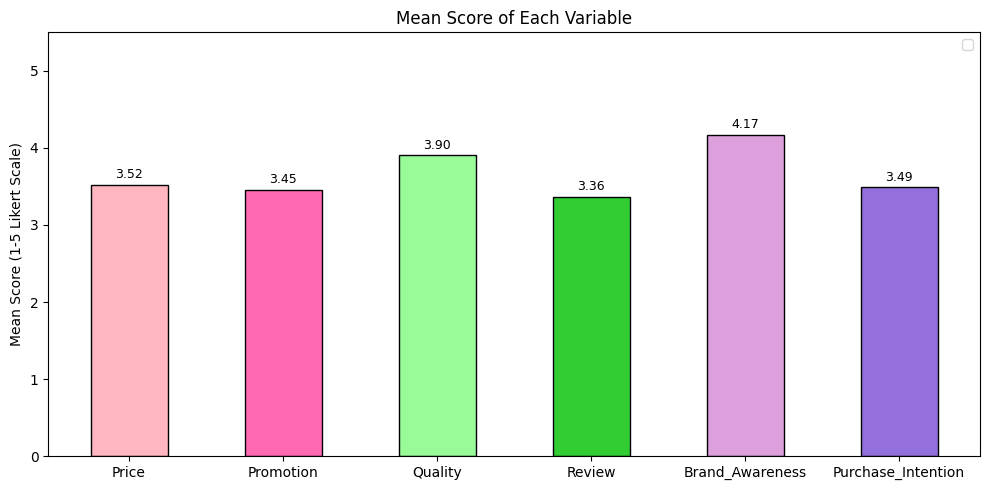

In [ ]:
#Bar chart showing the mean score of each variables
variables = ['Price', 'Promotion', 'Quality', 'Review', 'Brand_Awareness', 'Purchase_Intention']

means = final_df.mean().values

colors = ['#ffb6c1', '#ff69b4', '#98fb98', '#32cd32', '#dda0dd', '#9370db']

plt.figure(figsize=(10, 5))
bars = plt.bar(variables, means, edgecolor='black', width=0.5, color=colors)

plt.ylim(0, 5.5)

for bar, val in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.title("Mean Score of Each Variable")
plt.ylabel("Mean Score (1-5 Likert Scale)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#checking any missing data
total_responses = len(final_df)
missing_values  = final_df.isnull().sum().sum()

print(total_responses)
print(missing_values)

300
0


In [ ]:
target_col = "Y_Purchase_Intention"
X = final_df.drop(columns=[target_col])
y = final_df[target_col]
y_class = np.where(y >= 4, 1, 0)

In [ ]:
class_counts = pd.Series(y_class).value_counts().rename(
    {0: "Low Purchase Intention", 1: "High Purchase Intention"})
print("\nClass Distribution (below 4 considered as Low Purchase Intention):")
print(class_counts)


Class Distribution (below 4 considered as Low Purchase Intention):
Low Purchase Intention     176
High Purchase Intention    124
Name: count, dtype: int64


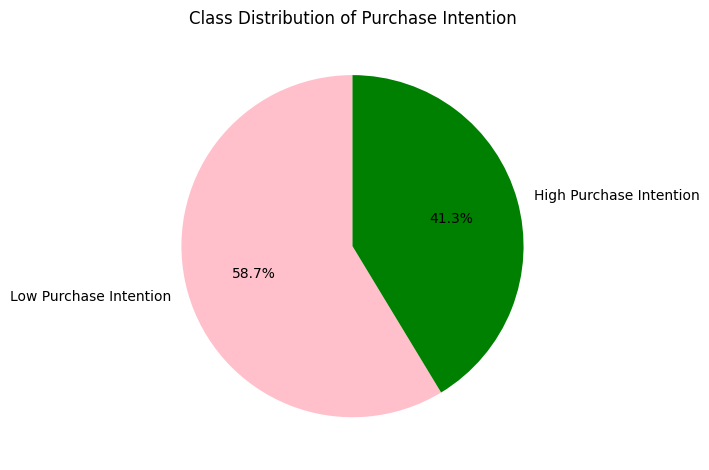

In [ ]:
plt.pie(class_counts.values, labels=class_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['pink', 'green'])

plt.title("Class Distribution of Purchase Intention")
plt.tight_layout()
plt.show()

**SECTION 4: CROSS VALIDATION**

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
#activation function
sigmoid = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(16, 8), activation="logistic", solver="adam", learning_rate_init=0.001, max_iter=1000, random_state=42))
])

In [ ]:
relu = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu", solver="adam", learning_rate_init=0.001, max_iter=1000, random_state=42))
])

In [ ]:
y_pred_sigmoid = cross_val_predict(sigmoid, X, y_class, cv=cv)
y_pred_relu = cross_val_predict(relu, X, y_class, cv=cv)

In [ ]:
cv_acc_sigmoid = cross_val_score(sigmoid, X, y_class, cv=cv, scoring='accuracy')
cv_acc_relu    = cross_val_score(relu, X, y_class, cv=cv, scoring='accuracy')

In [ ]:
cv_results = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(5)],
    "Sigmoid Accuracy": cv_acc_sigmoid.round(4),
    "ReLU Accuracy"   : cv_acc_relu.round(4)
})

In [ ]:
print(cv_results.to_string(index=False))
print(f"Mean Sigmoid Accuracy : {cv_acc_sigmoid.mean():.4f} ± {cv_acc_sigmoid.std():.4f}")
print(f"Mean ReLU Accuracy    : {cv_acc_relu.mean():.4f} ± {cv_acc_relu.std():.4f}")

  Fold  Sigmoid Accuracy  ReLU Accuracy
Fold 1            0.8833         0.8667
Fold 2            0.7500         0.7500
Fold 3            0.7667         0.7500
Fold 4            0.8500         0.7833
Fold 5            0.8000         0.7500
Mean Sigmoid Accuracy : 0.8100 ± 0.0501
Mean ReLU Accuracy    : 0.7800 ± 0.0452


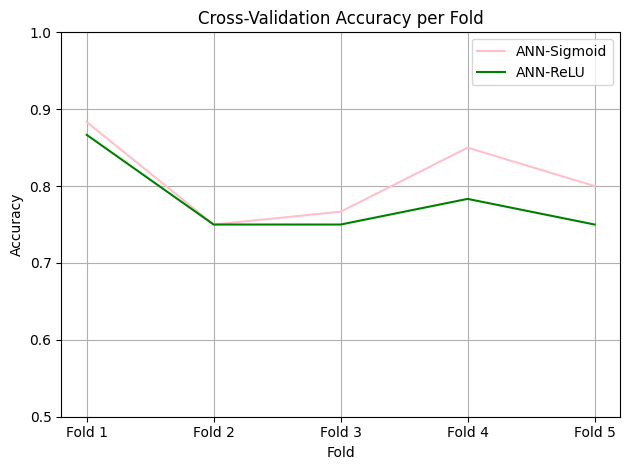

In [ ]:
plt.plot(range(1, 6), cv_acc_sigmoid, label='ANN-Sigmoid', color='pink')
plt.plot(range(1, 6), cv_acc_relu, label='ANN-ReLU', color='green')
plt.xticks(range(1, 6), [f"Fold {i}" for i in range(1, 6)])
plt.ylim(0.5, 1.0)
plt.title("Cross-Validation Accuracy per Fold")
plt.ylabel("Accuracy")
plt.xlabel("Fold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**SECTION 5: ANN-RELU & ANN-SIGMOID MODEL EVALUATION**

In [ ]:
print("\n--- ANN-SIGMOID CLASSIFICATION REPORT ---")
print(classification_report(y_class, y_pred_sigmoid, target_names=["Low Intention", "High Intention"]))


--- ANN-SIGMOID CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

 Low Intention       0.86      0.81      0.83       176
High Intention       0.75      0.81      0.78       124

      accuracy                           0.81       300
     macro avg       0.80      0.81      0.81       300
  weighted avg       0.81      0.81      0.81       300



In [ ]:
print("\n--- ANN-RELU CLASSIFICATION REPORT ---")
print(classification_report(y_class, y_pred_relu, target_names=["Low Intention", "High Intention"]))


--- ANN-RELU CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

 Low Intention       0.80      0.84      0.82       176
High Intention       0.75      0.70      0.72       124

      accuracy                           0.78       300
     macro avg       0.77      0.77      0.77       300
  weighted avg       0.78      0.78      0.78       300



In [ ]:
metrics = {}
for name, pred in zip(["ANN-Sigmoid", "ANN-ReLU"], [y_pred_sigmoid, y_pred_relu]):
    metrics[name] = {
        "Accuracy": accuracy_score(y_class, pred),
        "Precision": precision_score(y_class, pred),
        "Recall": recall_score(y_class, pred),
        "F1-Score": f1_score(y_class, pred),
        "CM": confusion_matrix(y_class, pred)
    }

In [ ]:
comparison = pd.DataFrame(metrics).T.drop(columns=["CM"]).reset_index().rename(columns={"index": "Model"})
print("\n--- MODEL EVALUATION RESULTS ---")
print(comparison.to_string(index=False))


--- MODEL EVALUATION RESULTS ---
      Model Accuracy Precision    Recall  F1-Score
ANN-Sigmoid     0.81  0.748148  0.814516  0.779923
   ANN-ReLU     0.78      0.75  0.701613     0.725


**SECTION 6: COMPARING MODEL EVALUATION**

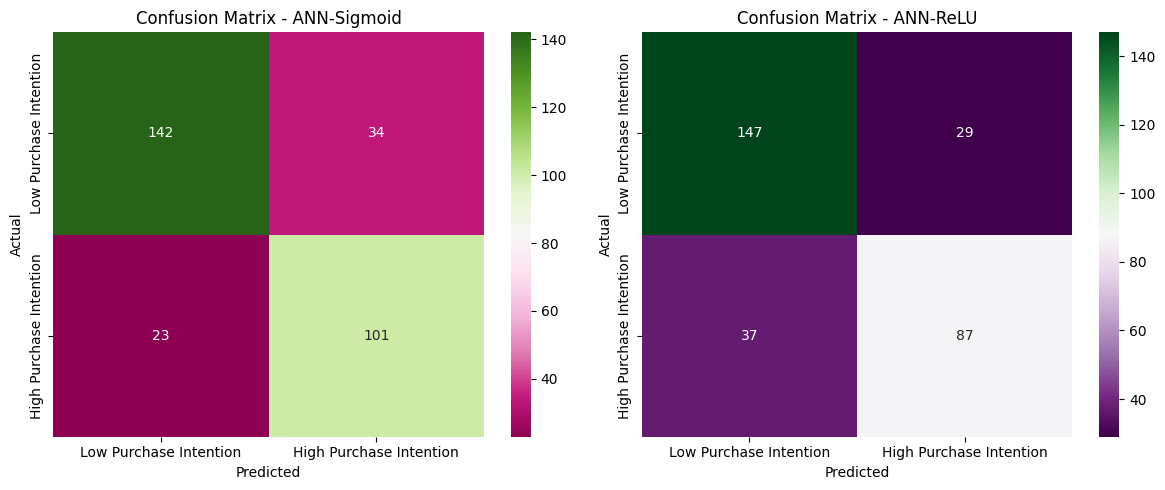

In [ ]:
#HeatMap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model_name, cmap in zip(axes, ["ANN-Sigmoid", "ANN-ReLU"], ["PiYG", "PRGn"]):
    sns.heatmap(metrics[model_name]["CM"], annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=["Low Purchase Intention", "High Purchase Intention"],
                yticklabels=["Low Purchase Intention", "High Purchase Intention"])
    ax.set_title(f"Confusion Matrix - {model_name}")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

**SECTION 7: BEST MODEL DECISION**

In [ ]:
best_acc = comparison.loc[comparison["Accuracy"].idxmax(), "Model"]
best_f1  = comparison.loc[comparison["F1-Score"].idxmax(), "Model"]

print(f"Best Model by Accuracy : {best_acc}")
print(f"Best Model by F1-Score : {best_f1}")

Best Model by Accuracy : ANN-Sigmoid
Best Model by F1-Score : ANN-Sigmoid


**SECTION 8: FEATURE IMPORTANCE**

In [ ]:
sigmoid.fit(X, y_class)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MLPClassifier(activation='logistic',
                               hidden_layer_sizes=(16, 8), max_iter=1000,
                               random_state=42))])

In [ ]:
perm_result = permutation_importance(
    sigmoid, X, y_class,
    n_repeats=30, random_state=42, scoring='accuracy')

In [ ]:
label_mapping = {
    "X1_Price": "Price",
    "X2_Promotion": "Promotion",
    "X3_Quality": "Quality",
    "X4_Review": "Customer Review",
    "X5_Brand_Awareness": "Brand Awareness"
}

In [ ]:
feat_imp = pd.DataFrame({
    'Feature': [label_mapping.get(col, col) for col in X.columns],
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False).reset_index(drop=True)

In [ ]:
display(feat_imp)

,Feature,Importance,Std
0,Quality,0.060333,0.019155
1,Customer Review,0.060111,0.017137
2,Price,0.047556,0.016995
3,Promotion,0.027889,0.012981
4,Brand Awareness,-0.004778,0.005753


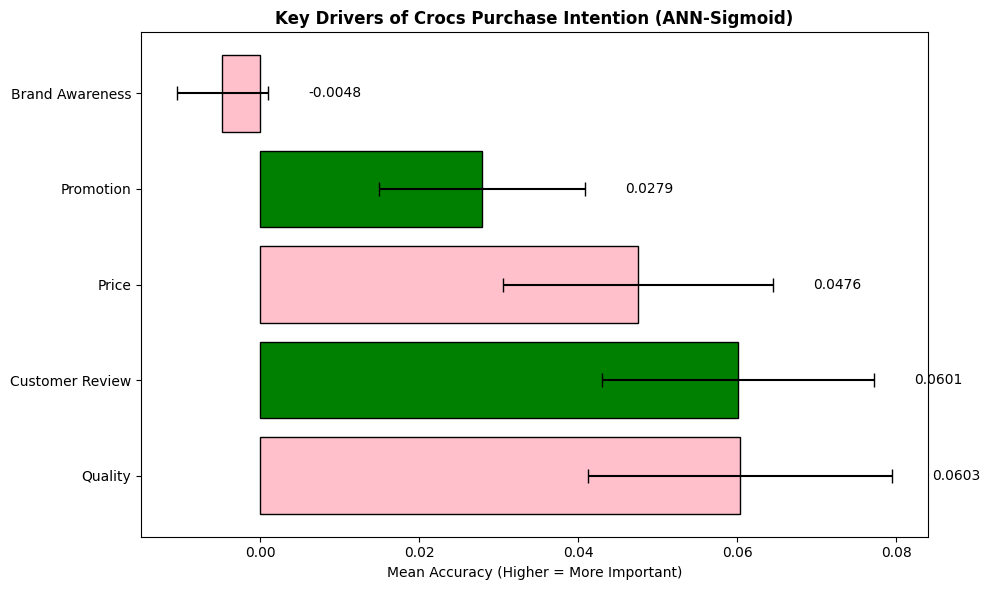

In [ ]:
plt.figure(figsize=(10, 6))

colors = ['pink', 'green', 'pink', 'green', 'pink']

bars = plt.barh(
    feat_imp['Feature'],
    feat_imp['Importance'],
    xerr=feat_imp['Std'],
    edgecolor='black',
    capsize=5,
    color=colors
)

plt.xlabel('Mean Accuracy (Higher = More Important)')
plt.ylabel('')
plt.title('Key Drivers of Crocs Purchase Intention (ANN-Sigmoid)', fontweight='bold')

for i, (val, std) in enumerate(zip(feat_imp['Importance'], feat_imp['Std'])):
    plt.text(val + std + 0.005, i, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()
